<a href="https://colab.research.google.com/github/JatinRaut23/Deep-Learning/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [23]:
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=10000)

In [24]:
x_train = pad_sequences(x_train,padding='post',maxlen=50)
x_test = pad_sequences(x_test,padding='post',maxlen=50)

In [25]:
model=Sequential()
model.add(Embedding(input_dim=10000, output_dim=2, input_length=50))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - acc: 0.5993 - loss: 0.6428 - val_acc: 0.7706 - val_loss: 0.4856
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.8128 - loss: 0.4165 - val_acc: 0.8022 - val_loss: 0.4333
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.8634 - loss: 0.3323 - val_acc: 0.8096 - val_loss: 0.4250
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - acc: 0.8890 - loss: 0.2805 - val_acc: 0.7964 - val_loss: 0.4655
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.9086 - loss: 0.2401 - val_acc: 0.8001 - val_loss: 0.4815
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.9229 - loss: 0.2078 - val_acc: 0.7938 - val_loss: 0.5096
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.9352 - loss: 0.1829 - val_acc: 0.7757 - val_loss: 0.6907
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.9432 - loss: 0.1602 - val_acc: 0.7801 - val_loss: 0.6017
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 

In [28]:
y_pred = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [29]:
y_pred_labels = (y_pred>0.5).astype(int)

In [30]:
for i in range(5):
  print('predicted:',y_pred_labels[i],'actual:',y_test[i])

predicted: [1] actual: 0
predicted: [1] actual: 1
predicted: [1] actual: 1
predicted: [1] actual: 0
predicted: [1] actual: 1


Text(95.72222222222221, 0.5, 'Truth')

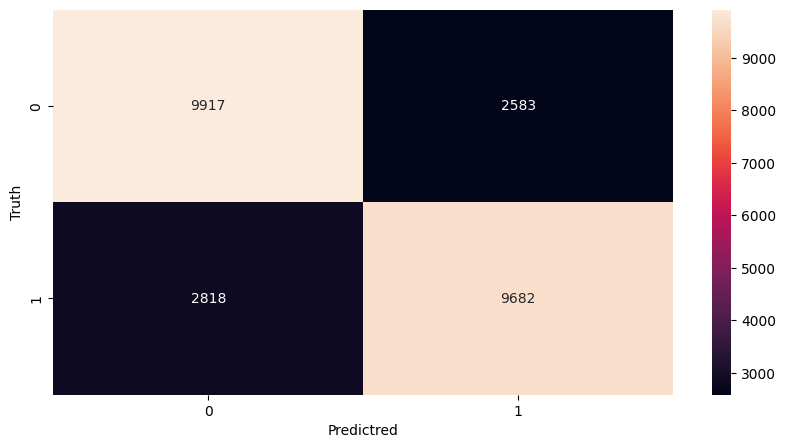

In [45]:
cm=tf.math.confusion_matrix(labels=y_test,predictions= y_pred_labels)
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predictred')
plt.ylabel('Truth')

[[9917 2583]
 [2818 9682]]


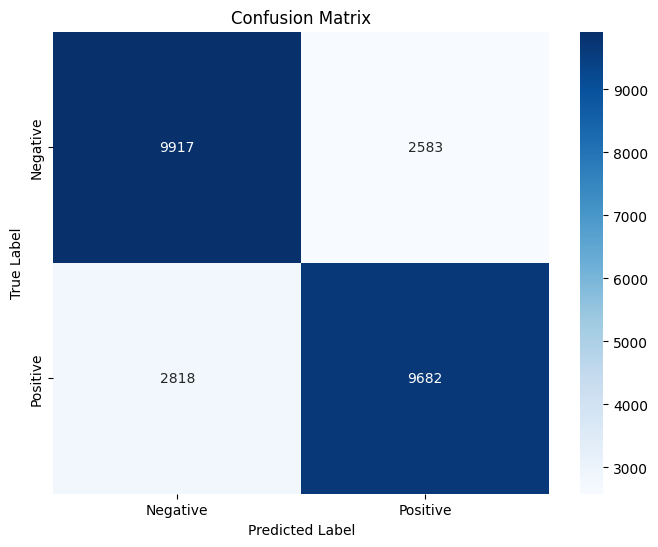

In [38]:
import seaborn as sns
cm=confusion_matrix(y_test, y_pred_labels)
print(cm)
plt.figure(figsize=(8,6))
ax=sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.show()

In [44]:
text = ['music was good story narration was excellent and acting was overacting']

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(text)

seq = tokenizer.texts_to_sequences(text)
padded = pad_sequences(seq, padding='post', maxlen=50)

prediction = model.predict(padded)
print("sentiment: ", "positive" if prediction > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
sentiment:  positive
